Generating Lunar Visibility Map...
Simulation Date: 2026-01-13 03:27:36 UTC


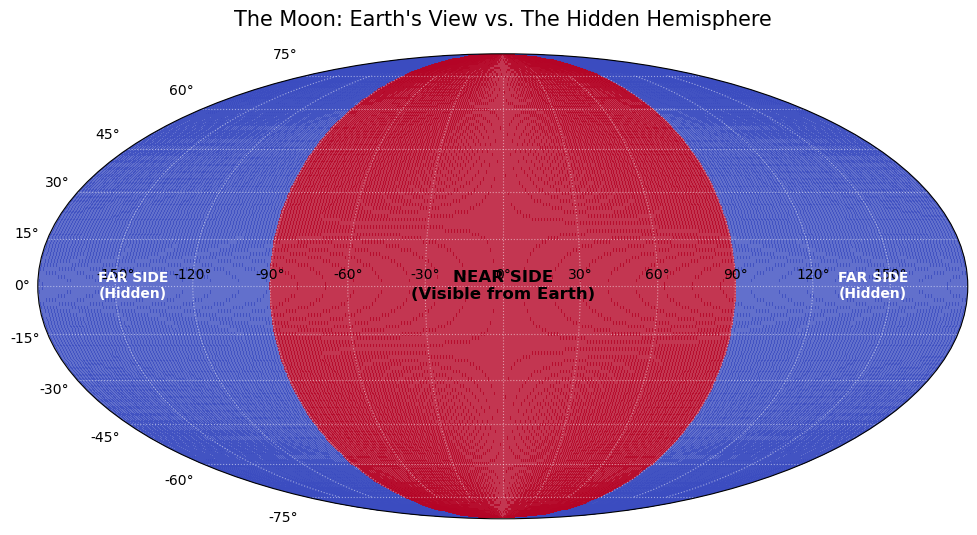

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skyfield.api import load, Topos

# 1. Setup standard data (These files are very stable and usually cached)
ts = load.timescale()
t = ts.now()
planets = load('de421.bsp')
earth, moon = planets['earth'], planets['moon']

# 2. Geometry: Calculate which side is facing Earth
# We get the position of the Moon relative to the Earth's center
astrometric = earth.at(t).observe(moon)
# We find the 'apparent' position to account for light travel time
ra, dec, distance = astrometric.radec()

# Because the moon is tidally locked, the 'Sub-Earth' longitude 
# is effectively 0 in the lunar coordinate system (mean Earth/polar axis).
# Libration (the wobble) is small (~5-7 degrees), so 0,0 is our anchor.
center_lon = 0
center_lat = 0

print(f"Generating Lunar Visibility Map...")
print(f"Simulation Date: {t.utc_strftime()}")

# 3. Create the Visualization
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='mollweide')

# Create a coordinate grid (Longitude -180 to 180, Latitude -90 to 90)
lon_grid = np.linspace(-np.pi, np.pi, 300)
lat_grid = np.linspace(-np.pi/2, np.pi/2, 150)
Lon, Lat = np.meshgrid(lon_grid, lat_grid)

# Logic: A point is visible if it's within 90 degrees of the center point (0,0)
# This uses the Great Circle distance formula
cos_c = (np.sin(center_lat) * np.sin(Lat) + 
         np.cos(center_lat) * np.cos(Lat) * np.cos(Lon - center_lon))

# 4. Define the regions
# Visible = 1, Far Side = 0
data = np.where(cos_c > 0, 1, 0)

# 5. Plotting
img = ax.pcolormesh(Lon, Lat, data, cmap='coolwarm', alpha=0.8, shading='auto')

# Add gridlines
ax.grid(True, color='white', linestyle=':', alpha=0.5)

# Annotations
ax.text(0, 0, "NEAR SIDE\n(Visible from Earth)", color='black', 
        ha='center', va='center', fontweight='bold', fontsize=12)
ax.text(-2.5, 0, "FAR SIDE\n(Hidden)", color='white', 
        ha='center', va='center', fontweight='bold')
ax.text(2.5, 0, "FAR SIDE\n(Hidden)", color='white', 
        ha='center', va='center', fontweight='bold')

plt.title("The Moon: Earth's View vs. The Hidden Hemisphere", pad=20, fontsize=15)
plt.show()